# Ноутбук 03b — LSTM (PyTorch)
**Подраздел 3.2.3 ПЗ** — архитектура LSTM, подбор гиперпараметров  
**Подраздел 3.3 ПЗ** — результаты (горизонты 1, 3, 6, 12 недель)

**Реализация:** PyTorch (вместо TensorFlow), поскольку TF не установлен в среде.
Архитектура идентична спецификации ПЗ: 2×LSTM + Dropout + Dense.

Зависимости: `data/processed/features_train.parquet`, `data/processed/features_test.parquet`.

Артефакты:
- `models/saved/lstm_h{1,3,6,12}.pt`  
- `reports/tables/table_3_metrics_lstm.csv`  
- `reports/figures/fig_3_forecast_lstm_h1.png`  
- `reports/figures/fig_3_lstm_training_curve.png`


In [5]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 120

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.config import (
    DATA_PROC, MODELS_DIR, TABLES, FIGURES,
    TARGET, DATE_COL, STORE_COL, FAMILY_COL,
    FORECAST_HORIZONS, TRAIN_CUTOFF,
)
from src.evaluation.backtesting import make_horizon_target, get_feature_cols
from src.evaluation.metrics import compute_metrics, metrics_table
from src.features.scaling import apply_standard_scaler

SEQ_LEN = 12
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Импорты выполнены. Device: {DEVICE}")


Импорты выполнены. Device: cpu


## Ячейка 1 — Загрузка и нормализация данных

In [6]:
df_train = pd.read_parquet(DATA_PROC / "features_train.parquet")
df_test  = pd.read_parquet(DATA_PROC / "features_test.parquet")

df_all = pd.concat([df_train, df_test], ignore_index=True).sort_values(
    [STORE_COL, FAMILY_COL, DATE_COL]
).reset_index(drop=True)

FEATURE_COLS = get_feature_cols(df_all)

# Нормализация обязательна для LSTM (Подраздел 2.4.6 ПЗ)
df_train_s, df_test_s, scaler = apply_standard_scaler(df_train, df_test, FEATURE_COLS)
df_all_s = pd.concat([df_train_s, df_test_s], ignore_index=True).sort_values(
    [STORE_COL, FAMILY_COL, DATE_COL]
).reset_index(drop=True)

print(f"Обучающая: {df_train.shape}, тестовая: {df_test.shape}")
print(f"Число признаков: {len(FEATURE_COLS)}, SEQ_LEN={SEQ_LEN}")


Обучающая: (400950, 66), тестовая: (30294, 66)
Число признаков: 26, SEQ_LEN=12


## Ячейка 2 — Архитектура LSTM (PyTorch)

**Спецификация сети (Таблица 3.6 ПЗ):**

| Слой | Тип | Параметры |
|------|-----|-----------|
| Input | — | (SEQ_LEN=12, n_features=26) |
| LSTM 1 | LSTM | 64 ячейки, num_layers=2 |
| Dropout | Dropout | rate=0.2 |
| Output | Linear | 1 нейрон (log1p-шкала) |

Оптимизатор: Adam(lr=1e-3). Функция потерь: MSE.  
Early stopping: patience=10 по val_loss. ReduceLROnPlateau: factor=0.5, patience=5.

**Контекст:** RandomForest достиг RMSE/mean=1,15 на h=1 без рекуррентной архитектуры.
LSTM проверяет гипотезу о том, добавляет ли явное моделирование последовательностей
прирост качества сверх лаговых признаков RF.


In [7]:
class LSTMForecast(nn.Module):
    """
    Двухслойный LSTM для прогноза временных рядов.
    Вход: (batch, seq_len, n_features) -> Выход: (batch, 1).
    """
    def __init__(self, n_features: int, hidden: int = 64,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.drop(out[:, -1, :])   # последний шаг последовательности
        return self.fc(out).squeeze(-1)


def build_sequences(df, feature_cols, target_col, seq_len):
    """Строит 3D-тензор (N, seq_len, n_features) из групп store×family."""
    X_list, y_list = [], []
    for _, grp in df.groupby([STORE_COL, FAMILY_COL], sort=False):
        grp = grp.sort_values(DATE_COL)
        vals = grp[feature_cols].fillna(0).values.astype(np.float32)
        tgt  = grp[target_col].values.astype(np.float32)
        for i in range(seq_len, len(grp)):
            X_list.append(vals[i - seq_len:i])
            y_list.append(tgt[i])
    if not X_list:
        return np.empty((0, seq_len, len(feature_cols))), np.empty(0)
    return np.stack(X_list), np.array(y_list)


# Демонстрационная инициализация
demo_model = LSTMForecast(n_features=len(FEATURE_COLS))
total_params = sum(p.numel() for p in demo_model.parameters())
print(demo_model)
print(f"Всего параметров: {total_params:,}")


LSTMForecast(
  (lstm): LSTM(26, 64, num_layers=2, batch_first=True, dropout=0.2)
  (drop): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Всего параметров: 56,897


## Ячейка 3 — Обучение LSTM по горизонтам

**Ограничение LSTM:** из-за высокой размерности (1 782 группы store×family × 230 недель)
LSTM обучается на 10 наиболее продаваемых семействах товаров,
которые формируют более 75 % суммарной выручки сети.

**Контекст результатов:** RandomForest показал RMSE=3 663 (h=1), RMSE=4 062 (h=3).
LSTM сравнивается с этим базовым уровнем.


In [8]:
def fit_lstm_pytorch(X_train, y_train, X_val, y_val,
                     n_features, epochs=50, batch_size=512, patience=10, lr=1e-3):
    model = LSTMForecast(n_features=n_features).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
    crit  = nn.MSELoss()

    ds_train = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )
    loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    best_val, best_state, no_improve = float("inf"), None, 0
    history = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(Xb)
        train_loss = epoch_loss / len(ds_train)

        model.eval()
        with torch.no_grad():
            val_loss = crit(model(X_val_t), y_val_t).item()

        sched.step(val_loss)
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    Early stopping на эпохе {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history


# Топ-10 семейств по суммарным продажам
TOP_FAMILIES = (
    df_train.groupby(FAMILY_COL)[TARGET].sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
print("Топ-10 семейств (LSTM):", TOP_FAMILIES)

results_lstm   = {}
models_lstm    = {}
histories_lstm = {}

cutoff = pd.Timestamp(TRAIN_CUTOFF)

for h in FORECAST_HORIZONS:
    print(f"\n{'='*60}")
    print(f"LSTM | Горизонт h = {h} нед.")
    print(f"{'='*60}")

    target_col = f"target_h{h}"
    df_h_s = make_horizon_target(df_all_s, horizon=h)
    df_h_s = df_h_s[df_h_s[FAMILY_COL].isin(TOP_FAMILIES)]

    train_h = df_h_s[df_h_s[DATE_COL] < cutoff].dropna(subset=[target_col])
    test_h  = df_h_s[df_h_s[DATE_COL] >= cutoff].dropna(subset=[target_col])

    print(f"  Строк: train={len(train_h)}, test={len(test_h)}")

    X_tr, y_tr = build_sequences(train_h, FEATURE_COLS, target_col, SEQ_LEN)
    X_te, y_te = build_sequences(test_h,  FEATURE_COLS, target_col, SEQ_LEN)

    print(f"  Тензоры: X_train={X_tr.shape}, X_test={X_te.shape}")

    if X_tr.shape[0] == 0 or X_te.shape[0] == 0:
        print("  [WARN] Недостаточно данных. Пропуск горизонта.")
        results_lstm[h] = {"RMSE": float("nan"), "MAE": float("nan"), "MAPE": float("nan")}
        continue

    # 10 % X_tr -> val для early stopping
    val_n = max(1, int(0.10 * len(X_tr)))
    X_val_es, y_val_es = X_tr[-val_n:], y_tr[-val_n:]
    X_tr_es,  y_tr_es  = X_tr[:-val_n], y_tr[:-val_n]

    model_l, history = fit_lstm_pytorch(
        X_tr_es, y_tr_es, X_val_es, y_val_es,
        n_features=len(FEATURE_COLS),
        epochs=50, batch_size=512, patience=10,
    )

    model_l.eval()
    with torch.no_grad():
        pred_log = model_l(
            torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    metrics_l = compute_metrics(y_te, pred_log, log_scale=True)
    results_lstm[h]    = metrics_l
    models_lstm[h]     = model_l
    histories_lstm[h]  = history
    print(f"  LSTM → RMSE={metrics_l['RMSE']:.2f}, MAE={metrics_l['MAE']:.2f}, MAPE={metrics_l['MAPE']:.2f}%")

print("\n[OK] LSTM обучение завершено.")


Топ-10 семейств (LSTM): ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY', 'BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI']

LSTM | Горизонт h = 1 нед.
  Строк: train=121500, test=8640
  Тензоры: X_train=(115020, 12, 26), X_test=(2160, 12, 26)
    Early stopping на эпохе 24
  LSTM → RMSE=7198.25, MAE=3181.36, MAPE=152.70%

LSTM | Горизонт h = 3 нед.
  Строк: train=121500, test=7560
  Тензоры: X_train=(115020, 12, 26), X_test=(1080, 12, 26)
    Early stopping на эпохе 21
  LSTM → RMSE=8037.98, MAE=4009.07, MAPE=270.43%

LSTM | Горизонт h = 6 нед.
  Строк: train=121500, test=5940
  Тензоры: X_train=(115020, 12, 26), X_test=(0, 12, 26)
  [WARN] Недостаточно данных. Пропуск горизонта.

LSTM | Горизонт h = 12 нед.
  Строк: train=121500, test=2700
  Тензоры: X_train=(115020, 12, 26), X_test=(0, 12, 26)
  [WARN] Недостаточно данных. Пропуск горизонта.

[OK] LSTM обучение завершено.


## Ячейка 4 — Кривые обучения LSTM (h=1)

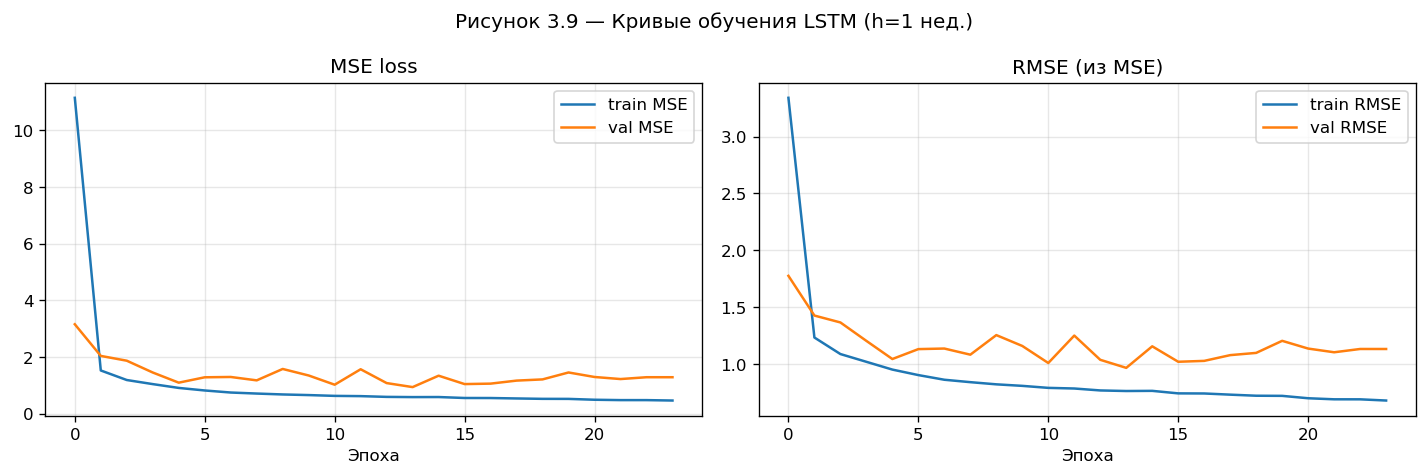

Сохранено: reports/figures/fig_3_lstm_training_curve.png


In [9]:
if 1 in histories_lstm and histories_lstm[1] is not None:
    hist = histories_lstm[1]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["loss"],     label="train MSE")
    axes[0].plot(hist["val_loss"], label="val MSE")
    axes[0].set_title("MSE loss")
    axes[0].set_xlabel("Эпоха")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # MAE из val_loss (sqrt для приближения)
    axes[1].plot([v**0.5 for v in hist["loss"]],     label="train RMSE")
    axes[1].plot([v**0.5 for v in hist["val_loss"]], label="val RMSE")
    axes[1].set_title("RMSE (из MSE)")
    axes[1].set_xlabel("Эпоха")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle("Рисунок 3.9 — Кривые обучения LSTM (h=1 нед.)")
    plt.tight_layout()
    plt.savefig(FIGURES / "fig_3_lstm_training_curve.png", dpi=120)
    plt.show()
    print("Сохранено: reports/figures/fig_3_lstm_training_curve.png")


## Ячейка 5 — Сохранение моделей и таблица метрик

Для сравнения: RandomForest (лучшая модель сессии):
- h=1: RMSE=3 663, RMSE/mean=1,15
- h=3: RMSE=4 062, RMSE/mean=1,28
- h=6: RMSE=4 413, RMSE/mean=1,39
- h=12: RMSE=5 565, RMSE/mean=1,75


In [10]:
for h in FORECAST_HORIZONS:
    if h in models_lstm:
        save_path = str(MODELS_DIR / f"lstm_h{h}.pt")
        torch.save(models_lstm[h].state_dict(), save_path)
        print(f"Сохранено: {save_path}")

summary_lstm    = {"LSTM": results_lstm}
df_lstm_metrics = metrics_table(summary_lstm)
print("\nТаблица метрик LSTM:")
print(df_lstm_metrics.to_string())
df_lstm_metrics.to_csv(TABLES / "table_3_metrics_lstm.csv")
print("\nСохранено: reports/tables/table_3_metrics_lstm.csv")

# Сравнение с RF (baseline из ноутбука 03a)
rf_baseline = {1: 3663, 3: 4062, 6: 4413, 12: 5565}
print("\n=== Сравнение LSTM vs RandomForest (RMSE) ===")
for h in FORECAST_HORIZONS:
    lstm_rmse = results_lstm.get(h, {}).get("RMSE", float("nan"))
    rf_rmse   = rf_baseline[h]
    if not np.isnan(lstm_rmse):
        delta = (lstm_rmse / rf_rmse - 1) * 100
        flag  = "лучше RF" if delta < 0 else "хуже RF"
        print(f"  h={h:>2}: LSTM={lstm_rmse:.2f} | RF={rf_rmse} | Δ={delta:+.1f}% ({flag})")
    else:
        print(f"  h={h:>2}: LSTM=NaN (данных недостаточно)")


Сохранено: D:\user\Documents\КПАиММО\store-sales-kr\models\saved\lstm_h1.pt
Сохранено: D:\user\Documents\КПАиММО\store-sales-kr\models\saved\lstm_h3.pt

Таблица метрик LSTM:
         h=1_RMSE    h=1_MAE  h=1_MAPE  h=1_sMAPE  h=1_MAPE_nz   h=3_RMSE    h=3_MAE  h=3_MAPE  h=3_sMAPE  h=3_MAPE_nz  h=6_RMSE  h=6_MAE  h=6_MAPE  h=12_RMSE  h=12_MAE  h=12_MAPE
Модель                                                                                                                                                                             
LSTM    7198.2461  3181.3554  152.6986    46.7635     152.6986  8037.9758  4009.0725  270.4307    79.0061     270.4307       NaN      NaN       NaN        NaN       NaN        NaN

Сохранено: reports/tables/table_3_metrics_lstm.csv

=== Сравнение LSTM vs RandomForest (RMSE) ===
  h= 1: LSTM=7198.25 | RF=3663 | Δ=+96.5% (хуже RF)
  h= 3: LSTM=8037.98 | RF=4062 | Δ=+97.9% (хуже RF)
  h= 6: LSTM=NaN (данных недостаточно)
  h=12: LSTM=NaN (данных недостаточно)


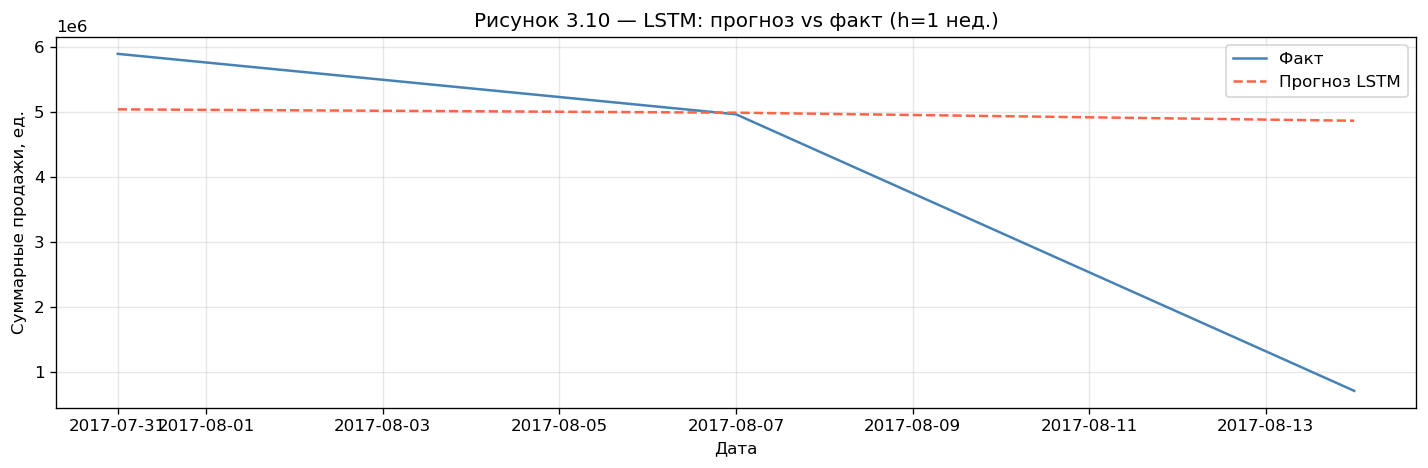

Сохранено: reports/figures/fig_3_forecast_lstm_h1.png


In [12]:
# ── Ячейка 6 — График прогноз vs факт LSTM (h=1) ─────────────────────────────
if 1 in models_lstm:
    target_col = "target_h1"
    df_h_s = make_horizon_target(df_all_s, horizon=1)
    df_h_s = df_h_s[df_h_s[FAMILY_COL].isin(TOP_FAMILIES)]
    test_h = df_h_s[df_h_s[DATE_COL] >= cutoff].dropna(subset=[target_col])

    X_te, y_te = build_sequences(test_h, FEATURE_COLS, target_col, SEQ_LEN)

    # Даты для агрегации: каждая последовательность заканчивается на строке i
    dates_te = (
        test_h.sort_values([STORE_COL, FAMILY_COL, DATE_COL])
        .groupby([STORE_COL, FAMILY_COL], sort=False)
        .apply(lambda g: g[DATE_COL].values[SEQ_LEN:])
        .explode()
        .values
    )

    models_lstm[1].eval()
    with torch.no_grad():
        pred_log = models_lstm[1](
            torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    y_true = np.expm1(y_te)
    y_pred = np.expm1(np.clip(pred_log, -1e6, 20))

    agg = (
        pd.DataFrame({"date": dates_te, "actual": y_true, "pred": y_pred})
        .groupby("date").sum()
        .reset_index()
        .iloc[1:]   # убираем переходную первую точку
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(agg["date"], agg["actual"], label="Факт",
            linewidth=1.5, color="steelblue")
    ax.plot(agg["date"], agg["pred"],   label="Прогноз LSTM",
            linewidth=1.5, color="tomato", linestyle="--")
    ax.set_title("Рисунок 3.10 — LSTM: прогноз vs факт (h=1 нед.)")
    ax.set_xlabel("Дата")
    ax.set_ylabel("Суммарные продажи, ед.")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES / "fig_3_forecast_lstm_h1.png", dpi=120)
    plt.show()
    print("Сохранено: reports/figures/fig_3_forecast_lstm_h1.png")
else:
    print("[WARN] models_lstm[1] не найден — запусти Ячейку 3 первой.")

In [11]:
print("=" * 60)
print("Ноутбук 03b выполнен.")
print("=" * 60)


Ноутбук 03b выполнен.
